4 0.15234375 0.6609375 0.30390625 0.678125
4 0.4578125 0.79140625 0.32421875 0.4171875
(640, 640)


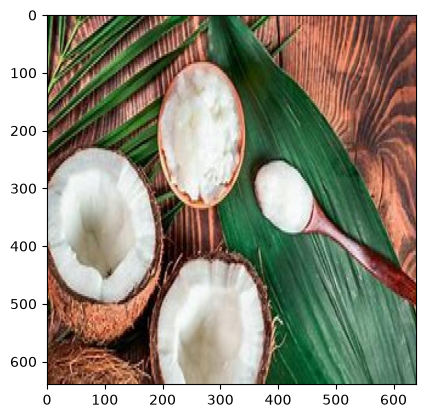

In [21]:
import os

common_path = "images/fruits2"

test_txt_file = os.path.join(common_path, "train/labels/1_jpg.rf.b02016afa0fdbaa23ffd1a64e1b9716c.txt")

with open(test_txt_file, encoding="utf-8") as f:
    content = f.read()
    print(content)

import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

test_img_file = os.path.join(common_path, "train/images/1_jpg.rf.b02016afa0fdbaa23ffd1a64e1b9716c.jpg")
image = Image.open(test_img_file).convert("RGB")
plt.imshow(image)
print(image.size)
# plt.xticks(np.arange(0, 1001, 100))
# plt.yticks(np.arange(0, 1001, 100))
# plt.axis("off")
plt.show()

In [26]:
# train/labels/에 있는 모든 .txt 파일을 순회하고 각 클래스별로 데이터가 몇 개 있는지 찍어보자.
train_label_path = os.path.join(common_path, "train/labels")

label_list = []

for txt_file in os.listdir(train_label_path):
    with open(os.path.join(train_label_path, txt_file), encoding="utf-8") as f:
        lines = f.readlines()
        for line in lines:
            # print(f"aa: {line}")
            # print(line[:1])
            label = int(line[:1])
            label_list.append(label)

from collections import Counter
label_counts = Counter(label_list)
print(type(label_counts))

<class 'collections.Counter'>


In [30]:
print(label_counts)

Counter({1: 2742, 0: 674, 6: 664, 2: 611, 8: 452, 7: 402, 9: 380, 4: 354, 5: 304, 3: 238})


[674, 2742, 611, 238, 354, 304, 664, 402, 452, 380, 0, 0, 0, 0, 0, 0]


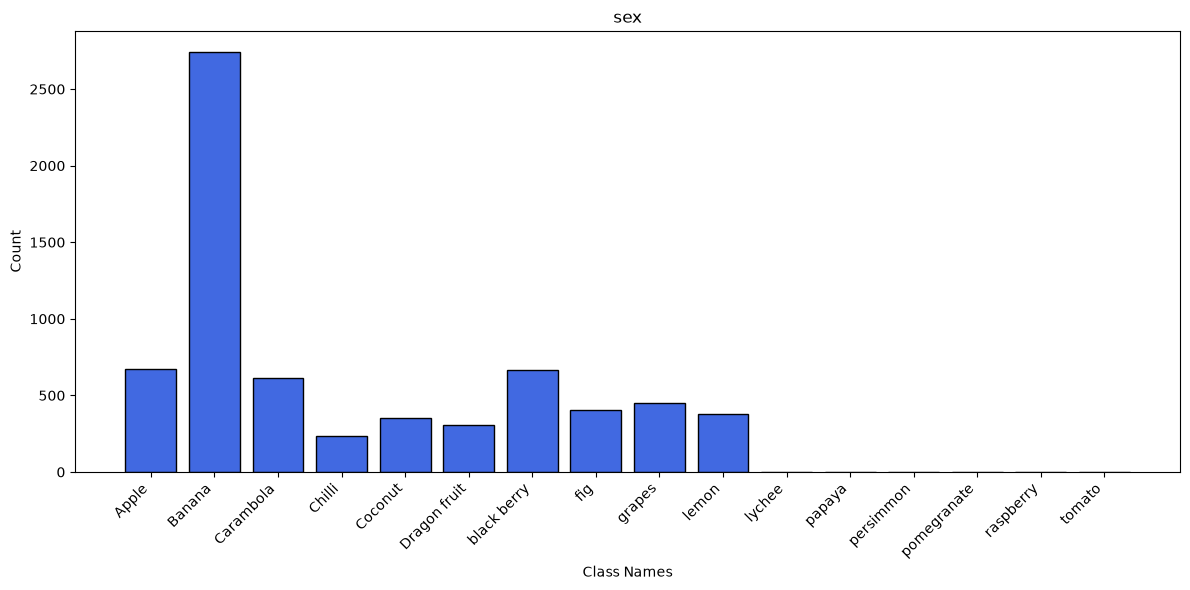

In [35]:
import yaml

yaml_file = os.path.join(common_path, "data.yaml")
with open(yaml_file, encoding="utf-8") as f:
    yaml_data = yaml.safe_load(f)

categories = yaml_data["names"]

values = [label_counts.get(i, 0) for i in range(len(categories))]
print(values)

plt.figure(figsize=(12, 6))
plt.bar(categories, values, color="royalblue", edgecolor="black")

plt.title("sex")
plt.xlabel("Class Names")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [31]:

print(type(categories))
print(len(categories))

values = list(label_counts.values())
print(values)

# plt.bar(categories, values, color="skyblue", alpla=0.8)
# plt.title("sex")
# plt.show()

<class 'list'>
16
[674, 452, 2742, 402, 304, 238, 380, 611, 354, 664]


In [36]:
from ultralytics import YOLO

current_dir = os.getcwd()

model = YOLO("yolov8n.pt")

results = model.train(
    data=os.path.join(common_path, "data.yaml"), 
    epochs=1, 
    imgsz=640, 
    device="mps", 

    project=os.path.join(current_dir, "runs"), 
    name="fruits"
)

New https://pypi.org/project/ultralytics/8.4.90 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.87 🚀 Python-3.11.15 torch-2.12.0 MPS (Apple M4)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=images/fruits2/data.yaml, degrees=0.0, deterministic=True, device=mps, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=1, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=fruits, nbs=64, nms=Fa

In [ ]:
# 1에폭짜리 내 가중치 코드
model = YOLO("runs/fruits_1epoch/weights/best.pt")

results = model.track(source="", save=True)